In [67]:
import pandas as pd
import numpy as np
import anc2vec

embeddings = anc2vec.get_embeddings()

SNARE_PATH = '../files/sources/SNARE_uniprot.tsv' # Nuovo solo snare
SNARE_NONSNARE = '../files/sources/snare_nonsnare_uniprot.tsv' # Proteine di originale arrcchite
NONSNARE_LABELS_PATH = '../files/sources/snare_nonsnare_labels.csv' # Originale

In [68]:
# FUNZIONI UTILI

def merge_embeddings(go_list, go_to_embeddings):
    """
    Aggrega gli embedding sommando i vettori invece di fare la media.
    """
    embeddings = [go_to_embeddings[g.strip()] for g in go_list if g in go_to_embeddings]
    
    if not embeddings:  # Se la lista è vuota, ritorna un embedding nullo della stessa dimensione
        return np.zeros_like(next(iter(go_to_embeddings.values()))).tolist()

    return np.sum(embeddings, axis=0).tolist()  # Somma dei vettori

def embed_gos(nodes_path, sep=','):
    """
    Da in output un dataframe che associa ad ogni proteina (STRING id) il vettore di feature (embedding anc2vec).
    """
    if type(nodes_path) is pd.core.frame.DataFrame:
        nodes_df = nodes_path.copy()[['STRING', 'Gene Ontology IDs']]
    else:
        nodes_df = pd.read_csv(nodes_path, sep=sep)[['STRING', 'Gene Ontology IDs']]
    unique_go_ids = set(id.strip() for ids in nodes_df['Gene Ontology IDs'].str.split(';') for id in ids)
    go_to_embeddings = {go:embeddings[go] for go in unique_go_ids if go in embeddings}

    # Aggrega tutte le go di ogni record
    nodes_df['Gene Ontology IDs'] = nodes_df['Gene Ontology IDs'].apply(
        lambda x: merge_embeddings([go.strip() for go in x.split(';')], go_to_embeddings)
    )

    # Rimuovi ";" da nome
    nodes_df['STRING'] = nodes_df['STRING'].apply(
        lambda x: x.split(';')[0]
    )

    nodes_df.columns = ['STRING_id', 'GO_embeddings']
    return nodes_df

In [69]:
SNARE_embedded_df = embed_gos(SNARE_PATH, sep='\t')
SNARE_embedded_df.head()
samples = len(SNARE_embedded_df)

In [70]:
# PREPARO IL DATASET DI PROTEINE NON SNARE UMANE

# 1. Faccio merge del dataset arricchito con quello con le label
snare_labels = pd.read_csv(NONSNARE_LABELS_PATH)
nonsnare_df = pd.read_csv(SNARE_NONSNARE, sep='\t')[['Entry', 'Gene Ontology IDs', 'STRING', 'Entry Name', 'Organism']]
nonsnare_df = nonsnare_df[nonsnare_df['Organism'] == 'Homo sapiens (Human)']

nonsnare_df = pd.merge(nonsnare_df, snare_labels, left_on='Entry', right_on='PROTEIN_CODE UNIPROT')[['Entry', 'Gene Ontology IDs', 'STRING', 'Entry Name', 'LABEL']]

# 2. Pulisco i dati:
#       - Tolgo la dicitura _HUMAN dalle entry name
#       - Converto Gene Ontology IDs in lista di GO

nonsnare_df['Entry Name'] = nonsnare_df['Entry Name'].apply(
    lambda x : x.split('_')[0]
)

# 3. Seleziono solo i label non snare
nonsnare_df = nonsnare_df[nonsnare_df['LABEL'] == 'NONSNARE']
nonsnare_df

,Entry,Gene Ontology IDs,STRING,Entry Name,LABEL
0,O00499,GO:0000122; GO:0002020; GO:0005543; GO:0005634...,9606.ENSP00000316779;,BIN1,NONSNARE
1,O00571,GO:0003677; GO:0003678; GO:0003689; GO:0003723...,9606.ENSP00000494040;,DDX3X,NONSNARE
2,O00602,GO:0001664; GO:0001867; GO:0002752; GO:0003823...,9606.ENSP00000360871;,FCN1,NONSNARE
3,O14786,GO:0001525; GO:0001569; GO:0001570; GO:0001755...,9606.ENSP00000265371;,NRP1,NONSNARE
5,O15492,GO:0003924; GO:0005096; GO:0005516; GO:0005737...,9606.ENSP00000356529;,RGS16,NONSNARE
...,...,...,...,...,...
63,Q9UGN4,GO:0001786; GO:0002376; GO:0005886; GO:0007155...,9606.ENSP00000353259;,CLM8,NONSNARE
64,Q9UI36,GO:0000122; GO:0000977; GO:0000978; GO:0000981...,9606.ENSP00000482245;,DACH1,NONSNARE
65,Q9UKG1,GO:0001726; GO:0001786; GO:0005634; GO:0005737...,9606.ENSP00000288266;,DP13A,NONSNARE
66,Q9UKM7,GO:0004571; GO:0005509; GO:0005783; GO:0005789...,9606.ENSP00000360645;,MA1B1,NONSNARE


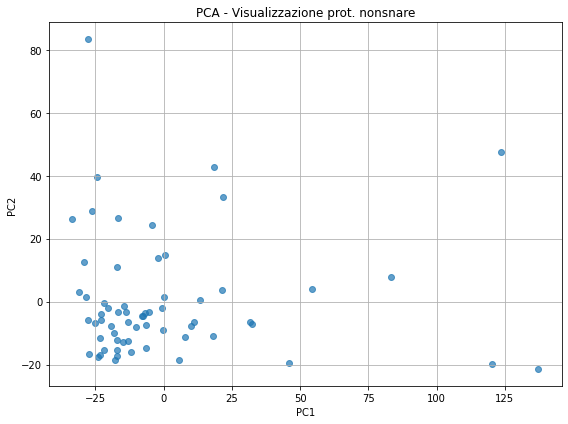

In [71]:
# ANALISI DEI DATI SUI DUE DATASET COSTRUITI AL MOMENTO (SOLO SNARE E SOLO NONSNARE)

# 1. Sostituzione GO con embedding (NONSNARE)
nonsnare_embedded_df = embed_gos(nonsnare_df)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_embeddings_pca(df, embedding_col="GO_embeddings", label_col=None, title="PCA degli Embedding"):
    embeddings = np.vstack(df[embedding_col].apply(eval) if isinstance(df[embedding_col].iloc[0], str) else df[embedding_col])
    
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(embeddings)
    
    plt.figure(figsize=(8, 6))
    if label_col:
        labels = df[label_col].values
        scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='plasma', alpha=0.7)
        plt.legend(*scatter.legend_elements(), title=label_col)
    else:
        plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.7)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_embeddings_pca(nonsnare_embedded_df, embedding_col="GO_embeddings", title="PCA - Visualizzazione prot. nonsnare")



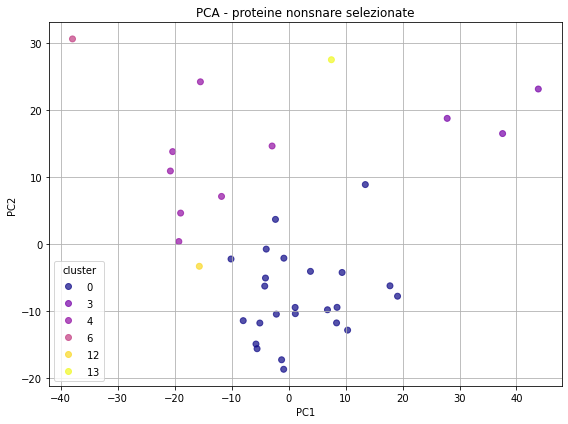

In [72]:
# Criterio di sampling:
# 1. Applicare k-means con k=15 (arbitrario)
# 2. Eliminare i sample che costituiscono l'unico elemento di un cluster (li tratto come outliers)
# 3. Campiono un numero di sample da ogni cluster proporzionale alla grandezza del cluster.

from sklearn.cluster import KMeans
import numpy as np

# Parametri
n_clusters = 15

embeddings = np.vstack(nonsnare_embedded_df["GO_embeddings"].values)

# 1. Clustering
kmeans = KMeans(n_clusters=n_clusters, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

clustered_df = nonsnare_embedded_df.copy()
clustered_df["cluster"] = cluster_labels

# 2. Rimozione dei cluster con un solo elemento (outlier)
valid_clusters = clustered_df["cluster"].value_counts()
valid_clusters = valid_clusters[valid_clusters > 1].index
filtered_df = clustered_df[clustered_df["cluster"].isin(valid_clusters)]

# 3.1 Ricalcolo proporzioni
cluster_sizes = filtered_df["cluster"].value_counts().sort_index()
cluster_proportions = (cluster_sizes / cluster_sizes.sum() * samples).round().astype(int)

# 3.2 Bilanciamento per ottenere esattamente 37 sample
diff = samples - cluster_proportions.sum()
if diff != 0:
    adjustment_index = cluster_proportions.idxmax() if diff > 0 else cluster_proportions[cluster_proportions > 1].idxmin()
    cluster_proportions[adjustment_index] += diff

# 3.3 Sampling proporzionale
sampled_dfs = [
    filtered_df[filtered_df["cluster"] == cluster].sample(n=n, random_state=42)
    for cluster, n in cluster_proportions.items()
]
sampled_df = pd.concat(sampled_dfs).reset_index(drop=True)

plot_embeddings_pca(sampled_df, label_col='cluster', title="PCA - proteine nonsnare selezionate")
sampled_df = sampled_df.drop(columns=['cluster'])

In [73]:
# UNIONE DATSET SNARE E NONSNARE(sampled)

sampled_df['label'] = 0
SNARE_embedded_df['label'] = 1

snare_nonsnare_df = pd.concat([SNARE_embedded_df, sampled_df], ignore_index=True)

In [74]:
# MAPPING A ID UNIVOCI E DIVISIONE IN FILE NODES E EDGES

snare_nonsnare_df.reset_index(inplace=True)
snare_nonsnare_df.rename(columns={'index': 'id'})

snare_nonsnare_df

,index,STRING_id,GO_embeddings,label
0,0,9606.ENSP00000249647,"[7.077271938323975, -1.610729694366455, 4.0270...",1
1,1,9606.ENSP00000461784,"[4.392323017120361, -0.7316040992736816, 3.603...",1
2,2,9606.ENSP00000360183,"[6.501339912414551, -1.7556288242340088, 4.339...",1
3,3,9606.ENSP00000222547,"[3.673008441925049, -1.080414891242981, 2.2019...",1
4,4,9606.ENSP00000356918,"[6.099010944366455, 0.5814636945724487, 3.8697...",1
...,...,...,...,...
69,69,9606.ENSP00000360522,"[5.818792819976807, 2.987234115600586, -0.4053...",0
70,70,9606.ENSP00000353259,"[4.9264020919799805, 0.8557701110839844, 1.032...",0
71,71,9606.ENSP00000483570,"[6.865100383758545, 0.47835445404052734, -2.51...",0
72,72,9606.ENSP00000264606,"[6.853320121765137, 1.3333370685577393, -0.145...",0


In [75]:
id_prot_dict = dict(zip(snare_nonsnare_df['STRING_id'], snare_nonsnare_df['index']))
id_prot_dict

edges_df = pd.read_csv('/home/developer/Documents/Tesi/files/sources/snare_nonsnare_edges.tsv', sep='\t')[['node1_string_id', 'node2_string_id']]
edges_df['num_id_1'] = edges_df['node1_string_id'].map(id_prot_dict)
edges_df['num_id_2'] = edges_df['node2_string_id'].map(id_prot_dict)

edges_df.to_csv('./pre_processing_output/snare_nonsnare_edges.csv', index=False)
snare_nonsnare_df.to_csv('./pre_processing_output/snare_nonsnare_nodes.csv', index=False)